# Introduction
This project is not only a the replication of the paper:

Lou, Dong. Polk, Christopher. "Comomentum: Inferring Arbitrage Activity from Return Correlations", London School of Economics. Jan 2021

But it is also a source where the theory behind each concept and method are explained.

First, it is important to define the main concepts this project is constructed on.

## Momentum

### Economic perspective
Momentum is defined as the trend that great performance stocks keep following in short-mid term and viceversa. It is a possitive feedback strategy: traders buy what already increased and sell what went down.

### Aplication
$$\text{momentum}_{i,t} = \sum_{k=4}^{51} \log(1 + r_{i,t-k})$$

This is, the sum of log-returns within the 48 weeks window skipping the most recent 4 weeks before $t$ (Previous year omitting the last month, the academic standard to avoid short term reversion).

Implementation:
```python
lagged = US_returns.shift(skip)      # skip = 4
momentum = np.log(lagged + 1).rolling(window=48, min_periods=48).sum()
```

### Assumptions and methodology decisions 
1. **Window period (`min_periods=48`)**: if there is just one missing return within the 48 weeks window, the momentum of the specific stock is NaN. There is no interpolation or any technique to fil the empty observations.
2. **Missing data**: around ~10.5% of NaN momentum observations are product of alive companies. Meanwhile, ~89.5% are non existing companies.
3. **Log-momentum vs. simple momentum **: we used log-retunrs instead of simple returns ($\prod(1+r)-1$). For the ranking, this is irrelevant, but the meaning of the coefficient and the scale changes.
4. **Cross-sectional standarization**: before using momentum as a regresor, we standardize each week (z-score) so $\beta_t$ can be compared in time, independent of the volatility of the specific week: $$z_{i,t} = \frac{\text{mom}_{i,t} - \overline{\text{mom}_t}}{\sigma(\text{mom}_t)}$$
   calculating **over the existing stocks sample of each week, not over the complete universe of assets**

### Relevant results
- Annualized mean of the standard momentum factor: `[TO COMPLETE]`
- Annualized volatility: `[TO COMPLETE]`
- Sharpe ratio: `[TO COMPLETE]`


## Comomentum

Measuring arbitrage activity in financial markets is an important concern for trading strategies. When many investors and funds simultaneously implement momentum strategies, their trades can generate price movements that are not fully explained by fundamental information or common risk factors. This behaviour may lead to overreaction, causing prices to deviate from their fundamental values and eventually revert.

Comomentum is a measure designed to capture arbitrage activity in momentum strategies. It measures the abnormal comovement among winner stocks and among loser stocks after controlling for common risk factors. The intuition is that when many momentum traders hold similar positions, their trading activity causes these stocks to move together more strongly than expected.

A key finding of the literature is that high comomentum is associated with crowded momentum trading, lower future momentum returns, higher volatility, and stronger return reversals. This result is particularly important because arbitrageurs are traditionally viewed as stabilizing market participants; however, in positive-feedback strategies such as momentum, excessive arbitrage activity can instead contribute to market instability.

 **low comomentum** → low activity → momentum shows underreaction → we expect positive momentum returns and no reversion.
- **high comomentum** → crowded momentum strategy → possible overreaction → we expect momentum returns reversion.


# Data

US_Returns.csv: Weekly total stock returns (including reinvested dividends) in decimals.

US_live.csv: A dummy variable which indicates when a company was live (dummy = 1) and
when it was dead (dummy = 0).

FamaFrench.csv: Weekly factor returns of the three Fama-French factors, namely the
market excess return over the risk-free rate (Mkt-RF), the size factor (SMB) and the value
factor (HML). The risk-free rate (RF) is also given but it is not a separate factor. 



## Cross sectional Momentum
The next step is to run a cross-sectional regression where we are going to regress the cross sectional momentum of the market (all live stocks) on the future returns.

There are some important observations for the following steps:
- We are using a cummulative log momentum, this will affect the interpretation of $\beta$. This will be return per units of log-momentum but it will be difficult to compare this result with following weeks if the momentum changes much, the solution would be to standardize momentum

- To do so, we will get z score, subtracting the mean dividing it by the variance, this will turn the $\beta$ into extra returns asociated to moving standard deviations in the cross sectional ranking


# OLS Regression Theory

OLS makes the following assumptions so the estimators are unbiassed and efficient.


The residuals of the regression have zero mean, or its expected value is zero. <br>
$
\mathbb{E} (\epsilon) = 0
$

The residuals are independent of x <br>
$
\mathbb{E}(\epsilon | X) = \mathbb{E}(\epsilon)
$

The residuals are normally distributed



## Regresión Fama-MacBeth (Fama & MacBeth, 1973)

### El procedimiento de dos etapas
**Etapa 1 (cross-sectional, semana a semana):**
Para cada semana $t$, se corre una regresión transversal usando los stocks como unidad de observación:

$$r_{i,t+1} = \alpha_t + \beta_t \cdot z_{i,t} + \varepsilon_{i,t}, \qquad i = 1, ..., N_t$$

donde $z_{i,t}$ es el momentum estandarizado (Bloque 2) y $N_t$ es el número de stocks vivos y con datos válidos esa semana. Esto da una serie de tiempo de coeficientes $\{\beta_{52}, \beta_{53}, ..., \beta_T\}$ — el "factor return" del momentum, semana a semana.

**Etapa 2 (serie de tiempo, sobre los betas):**
$$\bar\beta = \frac{1}{T}\sum_t \beta_t \qquad SE(\bar\beta) = \frac{\sigma(\beta_t)}{\sqrt{T}} \qquad t\text{-stat} = \frac{\bar\beta}{SE(\bar\beta)}$$

Este t-stat es el resultado central del método: responde si el premio de momentum, en promedio a través de toda la muestra, es estadísticamente distinto de cero — análogo al t-stat de -3.35 que reporta el paper original en su Tabla III (aunque ellos usan long-short por deciles en vez de un regresor continuo).



### Por qué el procedimiento de dos etapas, y no una regresión pooled
Si en cambio corrieras una sola regresión sobre todo el panel (todas las semanas y todos los stocks juntos), los errores estándar estarían mal calculados, porque ignorarías la correlación entre stocks dentro de la misma semana (el mismo problema de comovimiento que motiva comomentum, Bloque 3). Fama-MacBeth evita esto al tratar cada semana como una unidad de observación independiente en la segunda etapa — es una forma temprana (1973) de lo que hoy se conoce como "clustering" de errores estándar.

### Filtros aplicados en la construcción de cada regresión semanal
1. Momentum estandarizado no-NaN en $t$.
2. Retorno no-NaN en $t+1$.
3. `US_live == 1` en $t+1$ — se exige vivo en la fecha del retorno que se está explicando, no en la fecha de formación del momentum, porque es en $t+1$ donde ocurre el evento económico (el retorno) que el modelo intenta explicar.
4. Se descarta la semana si el denominador de la fórmula cerrada de $\beta_t$ (varianza transversal de $x$) es efectivamente cero — evita división por cero en semanas con muy pocas observaciones o sin dispersión de momentum.

### Interpretación de $\beta_t$
Es la pendiente de la nube de puntos (momentum, retorno siguiente) para esa semana: cuánto retorno extra tuvo, en promedio, un stock por cada desviación estándar adicional de momentum respecto a la media transversal de esa semana. Acumulada en el tiempo, $\{\beta_t\}$ es equivalente al retorno de una estrategia long-short auto-financiada, ponderada continuamente por el momentum de cada stock (no solo por los deciles extremos).

### Resultados relevantes
- $\bar\beta$ (media semanal del factor): `[COMPLETAR]`
- $\bar\beta$ anualizado: `[COMPLETAR]`
- Desviación estándar anualizada: `[COMPLETAR]`
- t-stat de Fama-MacBeth: `[COMPLETAR]`
- Número de semanas efectivas (T con beta no-NaN): `[COMPLETAR]`


### Construction
For each stock, each week, we run a regression on Fama-French factors:

$$r_{i,\tau} = a_i + b_{i,\text{Mkt}} \cdot \text{MktRF}_\tau + b_{i,\text{SMB}} \cdot \text{SMB}_\tau + b_{i,\text{HML}} \cdot \text{HML}_\tau + \varepsilon_{i,\tau}$$

for $\tau \in [t-51, t]$. The residuals $\varepsilon_{i,\tau}$ capture the return of the stock that is not explained by the market risk, size or value.

Luego, dentro del decil ganador (top 10% por momentum) y del decil perdedor
(bottom 10%), se calcula la correlación pairwise promedio de estos residuos:

$$\text{CoMOM}^L = \text{avg. corr. pairwise de residuos, decil perdedor}$$
$$\text{CoMOM}^W = \text{avg. corr. pairwise de residuos, decil ganador}$$
$$\text{CoMOM} = 0.5 \times (\text{CoMOM}^W + \text{CoMOM}^L)$$

### Diferencia clave con la regresión de Fama-MacBeth (Bloque 4) — no confundir
| | Fama-MacBeth (momentum) | Comomentum |
|---|---|---|
| Tipo | Cross-sectional (por fecha) | Serie de tiempo (por stock) |
| Y | Retorno del stock en $t+1$ | Retorno del stock en $\tau$ |
| X | Momentum estandarizado | Factores Fama-French |
| Unidad de observación | Stocks (dentro de una semana) | Semanas (dentro de un stock) |
| Output usado | $\beta_t$ (serie en el tiempo) | Residuos $\varepsilon_{i,\tau}$ (para correlaciones) |

### Ajuste propuesto al momentum estándar usando comomentum
`[COMPLETAR una vez definida la regla de ajuste — Paso 5 del enunciado]`

### Resultados relevantes
- Media, min, max de CoMOM en la muestra: `[COMPLETAR]`
- Correlación entre CoMOM y el momentum ajustado: `[COMPLETAR]`

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import os

In [66]:
main_dir = project_root = os.path.dirname(os.getcwd())
data_dir = main_dir + "/data/processed/"


# Read data
#I make sure to use the correct columns
FamaFrench = pd.read_csv("../data/raw/FamaFrench.csv", usecols=["Date", "Mkt-RF", "SMB", "HML", "RF"])
#We convert the Date column to datetime format and set it as the index of the DataFrame
FamaFrench["Date"] = pd.to_datetime(FamaFrench["Date"], format="%Y%m%d")
FamaFrench.set_index("Date", inplace=True)
FamaFrenchSize = FamaFrench.shape

#I read the US_Dates.xlsx file and convert the Date column to datetime format
US_dates = pd.read_excel("../data/raw/US_Dates.xlsx",header = None)
US_dates.columns = ["Date"]
US_dates["Date"] = pd.to_datetime(US_dates["Date"], format="%Y%m%d")
US_datesSize = US_dates.shape

#I read the US_live.csv file
US_live = pd.read_csv("../data/raw/US_live.csv", header = None)
US_liveSize = US_live.shape
id_stock = np.arange(0, US_liveSize[1])
US_live = US_live.rename(columns = {US_live.columns[i]: id_stock[i] for i in range(len(US_live.columns))})

#I wont use the header of US_returns.csv, instead I will use the id_stock as column names
US_returns = pd.read_csv("../data/raw/US_Returns.csv", names = id_stock)
US_returnsSize = US_returns.shape

T, N = US_returns.shape

In [67]:
#Create a matrix to store the momentum values, initialized with NaN values
momentum = np.full((T, N), np.nan)

#Degfine the window and skip parameters for momentum calculation
#We will be looking back for 48 weeks, and we will skip the most recent 4 weeks
window = 48
skip = 4

#We will skip the first 4 weeks and save them in a variable called lagged
lagged= US_returns.shift(skip)
#We calculate the momentum using the rolling window
#We are using log returns to calculate the momentum
momentum = (np.log(lagged + 1)).rolling(window=window, min_periods=window).sum()

In [68]:
# Count valid returns for each date
# We are summing the number of non-NaN values for each row (date) in the momentum DataFrame
valid_counts = momentum.notna().sum(axis=1) 

#Define ranks for each date
# We are assigning ranks to the momentum values for each date, with the highest momentum getting rank 1 and the lowest getting rank N
ranks = momentum.rank(axis=1, ascending=False, method="first")

# Define the top and bottom deciles based on the ranks 
top_cutoff = np.ceil(valid_counts * 0.10).astype(int) 
bottom_cutoff = (valid_counts - top_cutoff + 1).astype(int)

top_decile_mask = ranks.le(top_cutoff, axis=0) & momentum.notna() 
bottom_decile_mask = ranks.ge(bottom_cutoff, axis=0) & momentum.notna()

top_decile = momentum.where(top_decile_mask)
bottom_decile = momentum.where(bottom_decile_mask)

In [69]:
# Debug row 1508 to understand the top/bottom decile split
row_idx = 1508
print(f"Row {row_idx} diagnostics:")
print(f"Valid momentum count: {valid_counts.iloc[row_idx]}")
print(f"Top cutoff: {top_cutoff.iloc[row_idx]}")
print(f"Bottom cutoff: {bottom_cutoff.iloc[row_idx]}")
print()

# Check which stocks have valid momentum in this row
valid_stocks = momentum.iloc[row_idx].dropna()
print(f"Number of stocks with valid momentum: {len(valid_stocks)}")
print()

# Check the ranks for this row
ranks_this_row = ranks.iloc[row_idx]
top_mask_this_row = top_decile_mask.iloc[row_idx]
bottom_mask_this_row = bottom_decile_mask.iloc[row_idx]

print(f"Stocks in top decile for row {row_idx}: {top_mask_this_row.sum()}")
print(f"Stocks in bottom decile for row {row_idx}: {bottom_mask_this_row.sum()}")
print()

# Show top and bottom momentum values for this row
print(f"Top decile values: {top_decile.iloc[row_idx].dropna().values[:5]}")
print(f"Bottom decile values: {bottom_decile.iloc[row_idx].dropna().values[:5]}")

Row 1508 diagnostics:
Valid momentum count: 1697
Top cutoff: 170
Bottom cutoff: 1528

Number of stocks with valid momentum: 1697

Stocks in top decile for row 1508: 170
Stocks in bottom decile for row 1508: 170

Top decile values: [0.60817575 0.51393359 0.65395436 0.42937709 0.52236016]
Bottom decile values: [-1.02372986 -0.91200933 -0.59389386 -0.91779661 -0.71348214]


In [70]:
#We take the real number of valid observations for each date, which is the number of non-NaN values in the momentum DataFrame
valid_obs = momentum.notna().sum(axis=1)
#We calculate the mean and standard deviation of the momentum values for each date, ignoring NaN values
mean = momentum.sum(axis = 1 )  / valid_obs
std = np.sqrt(((momentum.sub(mean, axis=0))**2).sum(axis=1) / valid_obs)
#We standardize the momentum values by subtracting the mean and dividing by the standard deviation for each date
momentum_std = momentum.sub(mean, axis = 0).div(std, axis=0)

### Note:

We will proceed running a regression of the momentum factor of the observation on the next period returns 

Filters for valid observations:

1- We will only consider momentum when the returns of the stocks one period after are not NaN

2- We will only consider momentum when there is one year of valid momentum data (i.e., at least 48 weeks without the 4 weeks skip of non-NaN values)

This filters are indeed rigid; we are excluding live companies that have missing data within the window. We calculate how many empty momentum observations we have and count how many of them were supposed to be active companies



In [71]:
# Count how many NaN observations are present.
momentum_nan = momentum.isna()
# Count how many times momentum is NaN while the company was "alive" according to US_live
mismatch = momentum_nan & (US_live == 1)
print(mismatch.sum().sum(), "NaN observations with live ticker")
print(momentum_nan.sum().sum(), "NaN observations in total")
print("Percentage of NaN observations with live ticker:", (mismatch.sum().sum() / momentum_nan.sum().sum()) * 100, "%")

961940 NaN observations with live ticker
9131281 NaN observations in total
Percentage of NaN observations with live ticker: 10.534556980559463 %


This result would not be a problem, so the filters can be assumed to be correct since only the 10 % of the NaN observations were supposed to have a valid value.

Now we proceed with the regression:

In [72]:
#Regression for just one observation
next_ret = US_returns.shift(-1)
next_live = US_live.shift(-1)

mask =  ((momentum_std.notna()) & (next_ret.notna()) & (next_live == 1))

x_valid  = momentum_std.where(mask)
y_valid = next_ret.where(mask)

x_mean = x_valid.mean(axis=1)
y_mean = y_valid.mean(axis=1)

x_dev = x_valid.sub(x_mean, axis=0)
y_dev = y_valid.sub(y_mean, axis=0)

num = (x_dev * y_dev).sum(axis=1)
div = (x_dev ** 2).sum(axis=1)

beta = num / div.where(div != 0, np.nan)  # Avoid division by zero
alpha = y_mean.sub(beta * x_mean, axis=0)

print(f"Alpha: {alpha.mean()}, with size {alpha.size}")
print(f"Beta: {beta.mean()}, with size {beta.size}")

Alpha: 0.0027044809016268353, with size 1513
Beta: 0.0001778505168220795, with size 1513


Fitted values mean: 0.00265095001047396, with size 10985893
Mean: 5.624396089653108e-20
Standard deviation: 0.04659772767804593


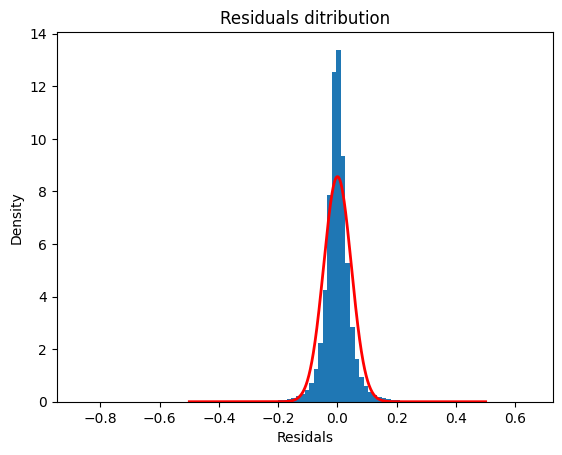

In [73]:
#We calculate the fitted values and residuals for the regression
fitted = x_valid.mul(beta, axis=0).add(alpha, axis=0)
print(f"Fitted values mean: {fitted.mean().mean()}, with size {fitted.size}")
residuals = y_valid.sub(fitted, axis=0)
mean_by_week = residuals.mean(axis=1, skipna=True) #Calculate the mean of the residuals for each week, ignoring NaN values

all_residuals = residuals.values.flatten()
all_residuals = all_residuals[~np.isnan(all_residuals)]

x_normal = np.linspace(-.5, .5, 1000)
y_normal = stats.norm.pdf(x_normal, loc=all_residuals.mean(), scale=all_residuals.std())


print("Mean:", all_residuals.mean())
print("Standard deviation:", all_residuals.std())

plt.hist(all_residuals, bins=100, density=True)
plt.xlabel("Residals")
plt.ylabel("Density")
plt.title("Residuals ditribution")
plt.plot(x_normal, y_normal, 'r-', linewidth=2)
plt.show()

In [74]:
# Calculate the t-statistic
# As we will use the mean of beta, we will calculate the standard error of beta and then compute the t-statistic
# Standard error of beta

se_beta = beta.std() / np.sqrt(len(beta.dropna()))
t_stat = beta.mean() / se_beta
print(f"T-statistic: {t_stat}")


n_valid = beta.notna().sum()
print(f"Semanas válidas: {n_valid}")
print(f"Beta promedio: {beta.mean():.5f}")
print(f"Desviación estándar de beta: {beta.std():.5f}")
print(f"SE: {se_beta:.5f}")
print(f"T-statistic: {t_stat:.3f}")

T-statistic: 0.6104573318178884
Semanas válidas: 1461
Beta promedio: 0.00018
Desviación estándar de beta: 0.01114
SE: 0.00029
T-statistic: 0.610


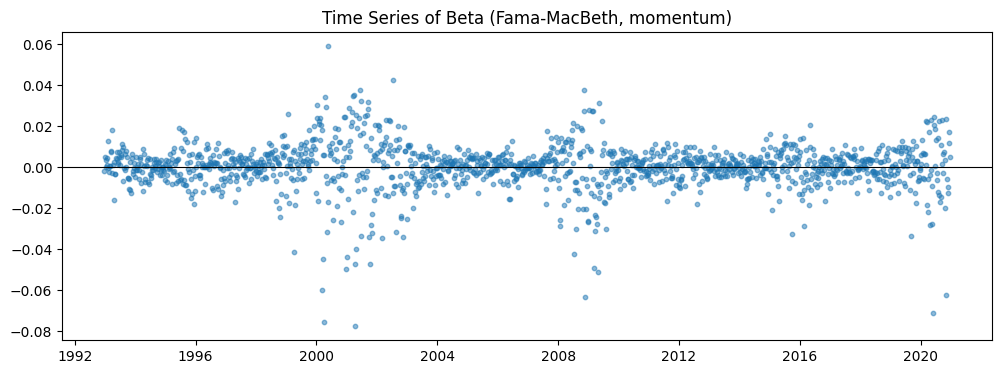

In [75]:
B = pd.DataFrame({'Date': US_dates['Date'], 'Beta': beta.values})
plt.figure(figsize=(12,4))
plt.scatter(B['Date'], B['Beta'], s=10, alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Time Series of Beta (Fama-MacBeth, momentum)")
plt.show()


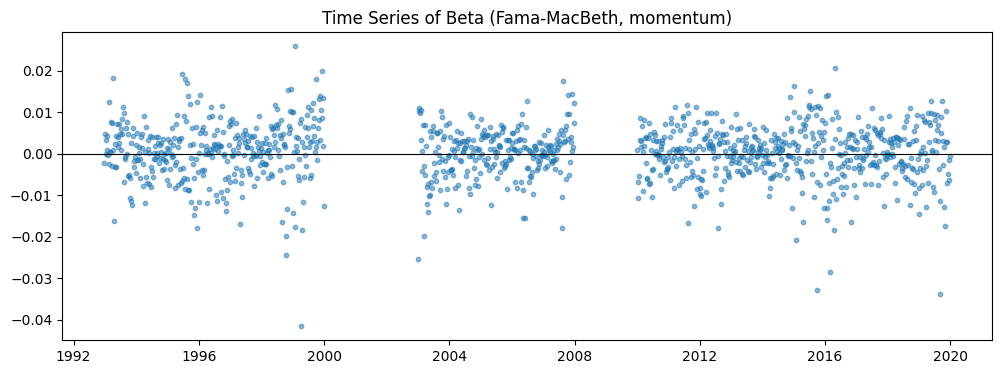

T-statistic: 1.6045555433396752
Valid weeks: 1150
Average Beta: 0.00031
Standard deviation of beta: 0.00664
SE: 0.00020
T-statistic: 1.605


In [ ]:
exclude = (
    ((US_dates["Date"] >= "2000-01-01") & (US_dates["Date"] <= "2002-12-31")) |
    ((US_dates["Date"] >= "2008-01-01") & (US_dates["Date"] <= "2009-12-31")) |
    ((US_dates["Date"] >= "2020-01-01") & (US_dates["Date"] <= "2020-12-31"))
)
excluding_dates = US_dates[~exclude]
excluding_beta = beta[~exclude]

B = pd.DataFrame({'Date': excluding_dates['Date'], 'Beta': excluding_beta.values})
plt.figure(figsize=(12,4))
plt.scatter(B['Date'], B['Beta'], s=10, alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Time Series of Beta (Fama-MacBeth, momentum)")
plt.show()


# Calculate the t-statistic
# As we will use the mean of beta, we will calculate the standard error of beta and then compute the t-statistic
# Standard error of beta


se_beta = excluding_beta.std() / np.sqrt(len(excluding_beta.dropna()))
t_stat = excluding_beta.mean() / se_beta
print(f"T-statistic: {t_stat}")



n_valid = excluding_beta.notna().sum()
print(f"Valid weeks: {n_valid}")
print(f"Average Beta: {excluding_beta.mean():.5f}")
print(f"Standard deviation of beta: {excluding_beta.std():.5f}")
print(f"SE: {se_beta:.5f}")
print(f"T-statistic: {t_stat:.3f}")



### Analysis

The previous results are not statistically significant. The chosen filters for momentum are introducing noise, making these results unreliable.

The results indicate that the momentum factor build on the returns of the market does not have any predictive power for the next returns. As a result, the way the momentum factor is built will be as the paper indicates; top winners and losers will build a long-short portfolio where the momentum factor will be constructed only by these sub-sample of assets.

Valid weeks: 1461
Average Long-Short Return: 0.00063
Standard Deviation: 0.03817
SE: 0.00100
T-statistic: 0.635


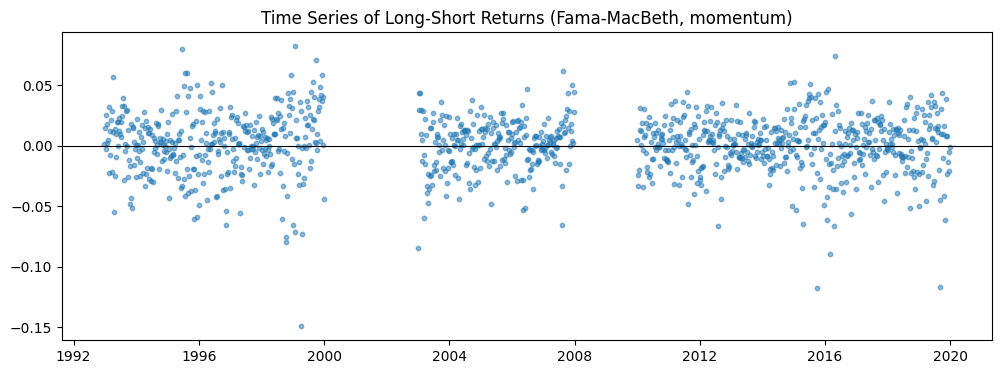

T-statistic: 1.7239162791470644
Valid weeks: 1150
Average Beta: 0.00121
Standard deviation of beta: 0.02376
SE: 0.00070
T-statistic: 1.724


In [ ]:
#Create a new mask to filter out the valid returns for the next week, considering only the stocks that are alive in the next week
live_t1 = US_live.shift(-1)
valid_t1 = next_ret.notna() & (live_t1 == 1)

#This mask returns a boolean DataFrame where True indicates that the stock is in the top decile and is valid for the next week, and False otherwise
winners_ret = next_ret.where(top_decile_mask & valid_t1)
losers_ret = next_ret.where(bottom_decile_mask & valid_t1)

#We calculate the average returns for the winners and losers for each date, ignoring NaN values
winners_avg = winners_ret.mean(axis=1)
losers_avg = losers_ret.mean(axis=1)

#We calculate the long-short return for each date
long_short = winners_avg - losers_avg

#Calculate the t-statistic for the long-short returns
se_ls = long_short.std() / np.sqrt(len(long_short.dropna()))
t_stat_ls = long_short.mean() / se_ls

#Print the results for the long-short returns
n_valid_ls = long_short.notna().sum()
print(f"Valid weeks: {n_valid_ls}")
print(f"Average Long-Short Return: {long_short.mean():.5f}")
print(f"Standard Deviation: {long_short.std():.5f}")
print(f"SE: {se_ls:.5f}")
print(f"T-statistic: {t_stat_ls:.3f}")

#Exclude the same dates as before for the long-short returns (crisis periods)

excluding_dates = US_dates[~exclude]
excluding_long_short = long_short[~exclude]

B = pd.DataFrame({'Date': excluding_dates['Date'], 'Beta': excluding_long_short.values})
plt.figure(figsize=(12,4))
plt.scatter(B['Date'], B['Beta'], s=10, alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Time Series of Long-Short Returns")
plt.show()


# Calculate the t-statistic
# As we will use the mean of beta, we will calculate the standard error of beta and then compute the t-statistic
# Standard error of beta
se_beta = excluding_long_short.std() / np.sqrt(len(excluding_long_short.dropna()))
t_stat = excluding_long_short.mean() / se_beta
print(f"T-statistic: {t_stat}")

n_valid = excluding_long_short.notna().sum()
print(f"Valid weeks: {n_valid}")
print(f"Average Beta: {excluding_long_short.mean():.5f}")
print(f"Standard deviation of beta: {excluding_long_short.std():.5f}")
print(f"SE: {se_beta:.5f}")
print(f"T-statistic: {t_stat:.3f}")